In [8]:
from typing import TypedDict
from typing_extensions import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import HumanMessage
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition

from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")

load_dotenv()

True

In [9]:
## create the state
class State(TypedDict):
    messages: Annotated[list, add_messages] ## you need add messages into the list type with the help of add_messages{reducer}


## llm object
llm_gai = ChatGoogleGenerativeAI(
            model = "gemini-3.5-flash-lite",
            max_tokens = 346,
)

In [6]:

## initialize
tavily_tool = TavilySearch(max_results=2)

tavily_tool.invoke("What is AI agent")


## tool - a human in a loop
@tool
def Human_assistance(Query: str) -> str:
    """
    Ask for human assistance
    """
    human_assitance = interrupt({"query": Query})
    return str(human_assitance["data"])


## list of tool
tools = [tavily_tool, Human_assistance]

## bind the llm with list of tools
llm_tools = llm_gai.bind_tools(tools)

In [10]:
## define tools
def tool_calling_llm(state: State):
    return {"messages": [llm_tools.invoke(state['messages'])]}

## Memory object
llm_memory = MemorySaver()


## Node graph 
builder = StateGraph(State)
builder.add_node("Saroj_tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## edge graph
builder.add_edge(START, "Saroj_tool_calling_llm")
builder.add_conditional_edges(
    "Saroj_tool_calling_llm",
    # if the latest message (result) from the assistance is a tool call -> tool_condition routes to tool
    # if the latest message (result) from the assistance is not a tool call -> tool_condition routes to END
    tools_condition
 )

builder.add_edge("tools", "Saroj_tool_calling_llm")

## compile the entire graph with memory
Bot_graph = builder.compile(checkpointer=llm_memory)


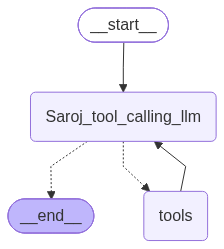

In [11]:
Bot_graph

In [13]:
## User inputs
user_input = "I need some expert guidance for building AI agents. Could you request assistance for me?"

## memory configuration
configs = {"configurable": {"thread_id": "human_id"}}

## invoke graph
events = Bot_graph.stream(
    {"messages": [user_input]},
    config=configs,
    stream_mode="values",
)

for response in events:
    if "messages" in response:
        response["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building AI agents. Could you request assistance for me?
================================== Ai Message ==================================

[]
Tool Calls:
  Human_assistance (call_1097939)
 Call ID: call_1097939
  Args:
    Query: The user needs expert guidance for building AI agents.
================================== Ai Message ==================================

[]
Tool Calls:
  Human_assistance (call_1097939)
 Call ID: call_1097939
  Args:
    Query: The user needs expert guidance for building AI agents.


In [14]:
## User inputs
human_resp= (
    "We, the expert are here to help! we'd recommand you to check out langgraph documents to build Ai agents.",
    "It is much reliable and extensible than simple autonomus chatbot."
)

human_command = Command(resume={"data": human_resp})

## memory configuration
configs = {"configurable": {"thread_id": "human_id"}}

## invoke graph
events_human_loop = Bot_graph.stream(
    human_command,
    config=configs,
    stream_mode="values",
)

for response in events_human_loop:
    if "messages" in response:
        response["messages"][-1].pretty_print()

================================== Ai Message ==================================

[]
Tool Calls:
  Human_assistance (call_1097939)
 Call ID: call_1097939
  Args:
    Query: The user needs expert guidance for building AI agents.
================================= Tool Message =================================
Name: Human_assistance

("We, the expert are here to help! we'd recommand you to check out langgraph documents to build Ai agents.", 'It is much reliable and extensible than simple autonomus chatbot.')
================================== Ai Message ==================================

[{'type': 'text', 'text': 'An expert has weighed in with some great advice! Here is what they recommend:\n\n> **"Check out LangGraph documentation to build AI agents. It is much more reliable and extensible than a simple autonomous chatbot."**\n\nIf you\'d like to dive deeper, we can break down how to get started with LangGraph, discuss agent architectures (like ReAct loops, multi-agent systems, or tool-